# Figure2(Stackedbar) for bertopic

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_4): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [2]:
import os 
import numpy as np
import pandas as pd
import lib.stats.stats as st
from utils.statistics import *
from setting_for_sda.constants import CONSTANTS
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

color_list = CONSTANTS.color_list
alpha_list = [1, 1, 0.7]

In [3]:
viz_dir = f'{CONSTANTS.data_root_dir}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = './fig/'
date_range = 'Weekly'



In [4]:
lst = os.listdir(data_dir)
df = pd.DataFrame()
for i in lst:
	js = load_json(f'{data_dir}/{i}')
	tmp = pd.DataFrame(js)
	tmp['json'] = i
	df = pd.concat([df, tmp], axis = 0)

In [5]:
df = df[['id', 'creationdate', 'Topic', 'json']].copy()

In [6]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed")
df['cdate'] = pd.to_datetime(df['creationdate'], format="%Y-%m-%d").dt.date
df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")


In [7]:
df['rel_week'] = np.floor((df['cdate']-\
                       CONSTANTS.year_range[option_dict['year_range']].get('std_date')).dt.days/7) 

In [8]:
df = df[(df['rel_week']>=-52) & ( df['rel_week']<52)].copy()

In [9]:
df['creationdate'].min(), df['creationdate'].max()

(Timestamp('2021-12-01 00:02:16.740000'),
 Timestamp('2023-11-28 23:50:44.193000'))

In [23]:
topic_list = list(df[(df['cdate']   >=  CONSTANTS.year_range[option_dict['year_range']].get('start_date'))&\
                 (df['cdate']       <   CONSTANTS.year_range[option_dict['year_range']].get('std_date'))]\
                .groupby('Topic').count()['id'].reset_index().sort_values(by = 'id', ascending=False)['Topic'])


top10list = topic_list[:10]
bot10list = topic_list[-10:]
mid30list = np.setdiff1d(np.arange(0,50), top10list)
mid30list = np.setdiff1d(mid30list, bot10list)



In [11]:
df.sort_values(by = ['cdate']).reset_index(drop=True, inplace=True)

In [12]:
df

,id,creationdate,Topic,json,cdate,rel_week
0,75299230,2023-01-31 15:15:40.263,41,31.json,2023-01-31,8.0
1,75299245,2023-01-31 15:17:00.660,0,31.json,2023-01-31,8.0
2,75299298,2023-01-31 15:20:53.143,44,31.json,2023-01-31,8.0
3,75299330,2023-01-31 15:23:07.533,13,31.json,2023-01-31,8.0
4,75299337,2023-01-31 15:24:05.363,29,31.json,2023-01-31,8.0
...,...,...,...,...,...,...
9995,76546246,2023-06-24 13:18:45.763,9,32.json,2023-06-24,29.0
9996,76546259,2023-06-24 13:22:18.747,15,32.json,2023-06-24,29.0
9997,76546278,2023-06-24 13:26:10.477,30,32.json,2023-06-24,29.0
9998,76546282,2023-06-24 13:27:45.180,33,32.json,2023-06-24,29.0


In [13]:
prop_df = pd.merge( df.groupby(['rel_week', 'Topic']).count()['id'].reset_index().rename(columns={'id': 'cnt'}),
                        df.groupby(['rel_week']).count()['id'].reset_index().rename(columns={'id': 'tot_cnt'}), on = 'rel_week')
prop_df['proportion'] = prop_df['cnt']/prop_df['tot_cnt']

In [14]:
df_coef = {'Entropy' : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_entropy(x)).to_frame(name='Entropy').reset_index(),
           'Gini'    : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_gini(x)).to_frame(name = 'Gini').reset_index()}

In [ ]:
def proportion_calc(df):
   
    df_tot = df.groupby('rel_week').count()['id'].reset_index(name = 'tot_cnt')
    df_topic = df.groupby(['rel_week', 'Topic']).count()['id'].reset_index(name = 'cnt')
    df_topic_r = pd.merge(df_topic, df_tot, on = 'rel_week')
    df_topic_r['pct'] = df_topic_r['cnt']/df_topic_r['tot_cnt']

    df_topic_r_t = df_topic_r[df_topic_r['Topic'].isin(top10list)]
    df_topic_r_b = df_topic_r[df_topic_r['Topic'].isin(bot10list)]
    # df_topic_r_m = df_topic_r[df_topic_r['Topic'].isin(mid30list)]

    

    proportion_dict = {'Top 20% Topics' : df_topic_r_t,
                        'Bottom 20% Topics' : df_topic_r_b, 
                        # 'Mid 60% Topics' : df_topic_r_m
                        }
    list_10 = {'Top 20% Topics' : top10list, 
               'Bottom 20% Topics' : bot10list,  
            #    "Mid 60% Topics" : mid30list
               }
    return proportion_dict, list_10


In [16]:
df_dict, list_10= proportion_calc(df)

0
1


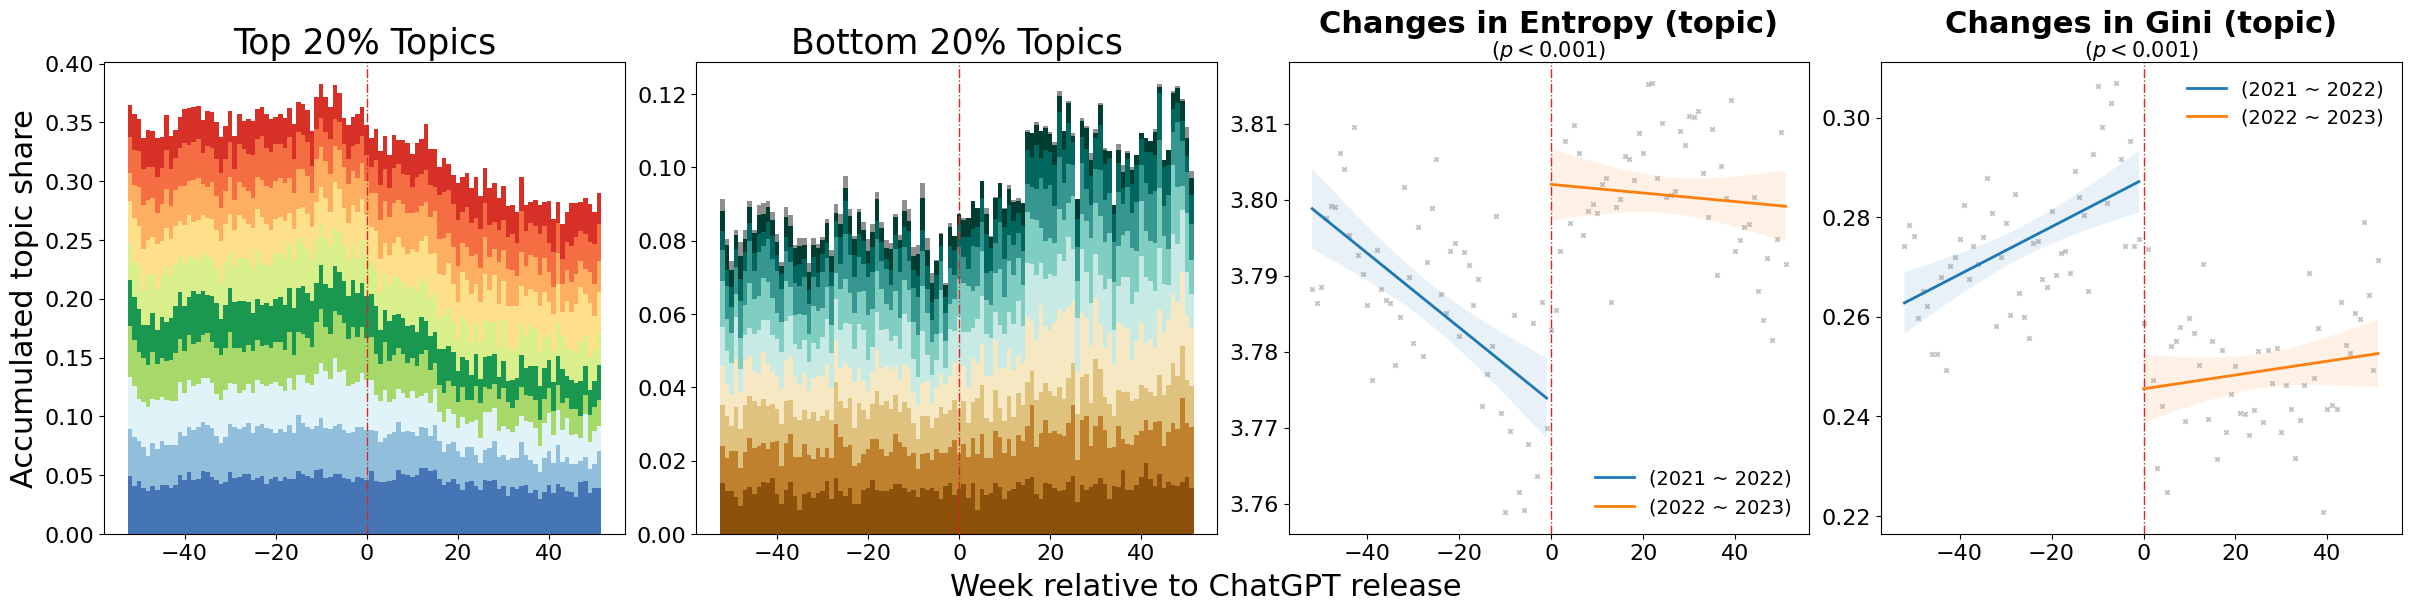

In [17]:

### create a figure with multiple subplots
sharey = True ## 또는 sharey=False
sharex = True ## 또는 sharex=False
# g_num  = len(proportion_dict.items())

fig, axs = plt.subplots(1, 4, figsize = (24, 6), constrained_layout=True)
colors = plt.get_cmap('tab20').colors 


for x, (title, proportion) in enumerate(df_dict.items()):
    rel_week = sorted(proportion['rel_week'].unique())  # 주차 순서 보장
    topic_list = list(proportion['Topic'].unique())
    order_list = list_10[title]
    print(x)
    colors = color_list[x]

    # 전체 주차 길이에 맞춰 bottom 초기화
    bottom = np.zeros(len(rel_week))
    

    for idx, topic in enumerate(order_list):
        # topic별 데이터
        t_p = proportion[proportion['Topic'] == topic]

        # topic별 주차별 비율을 rel_week 길이에 맞춰 채우기
        count_full = np.zeros(len(rel_week))
        for i, rw in enumerate(t_p['rel_week']):
            if rw in rel_week:
                rw_idx = rel_week.index(rw)
                count_full[rw_idx] = t_p.loc[t_p['rel_week'] == rw, 'pct'].values[0]

        # bar plot
        axs[x].bar(rel_week, count_full, bottom=bottom, label=topic, color=colors[idx], width=1.0, align='center', alpha=alpha_list[x])

        bottom += count_full  # 누적

    # 보조선 및 제목/레이블 등
    axs[x].axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)
    axs[x].set_title(f'{title}', fontsize=25)
    axs[x].tick_params(axis='x', labelsize=16)
    axs[x].tick_params(axis='y', labelsize=16)

axs[0].set_ylabel("Accumulated topic share", fontsize = 22)

for idx, (title, proportion) in enumerate(df_coef.items()):

    
    buff = 2
    idx+=buff
    list_ = proportion[title]
    x_rel, divider = get_dist_x_div(list_)

    reg_bf = calc_regression_with_ci(x_rel[:divider], list_[:divider])
    reg_af = calc_regression_with_ci(x_rel[divider:], list_[divider:])

    reg_bf_summary = reg_bf["pred_summary"]
    reg_af_summary = reg_af["pred_summary"]

    # 회귀선 (예측값)
    reg_bf_y_pred = reg_bf_summary["mean"]
    reg_af_y_pred = reg_af_summary["mean"]
    # 신뢰구간
    reg_bf_ci_lower = reg_bf_summary["mean_ci_lower"]
    reg_bf_ci_upper = reg_bf_summary["mean_ci_upper"]

    reg_af_ci_lower = reg_af_summary["mean_ci_lower"]
    reg_af_ci_upper = reg_af_summary["mean_ci_upper"]

    st_0 = st.Stats(np.array(np.arange(-52, 52)), list_, 2, 0.95)
    F_stat_0, p_value_0 = st_0.chow_test()
    p_value_txt = '($p < 0.001$)' if p_value_0 <0.001 else f'($p = {p_value_0:.3f}$)'

    axs[idx].scatter(x_rel, list_, color = 'darkgray', alpha = 0.7,  s=10, marker='x')
    axs[idx].axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)
    # axs[idx].set_ylabel(f"{measure} of Topic Distribution", fontsize = 10)
    
    txt_std = 2021
    axs[idx].plot(x_rel[:divider], reg_bf_y_pred, linewidth=2, label = f'({txt_std} ~ {txt_std+1})')
    axs[idx].plot(x_rel[divider:], reg_af_y_pred, linewidth=2, label = f'({txt_std+1} ~ {txt_std+2})')

    axs[idx].fill_between(x_rel[:divider], reg_bf_ci_lower, reg_bf_ci_upper, alpha=0.1)
    axs[idx].fill_between(x_rel[divider:], reg_af_ci_lower, reg_af_ci_upper, alpha=0.1)

    axs[idx].legend(frameon=False, loc='best', fontsize=14)
    

    axs[idx].tick_params(axis='x', labelsize=16)
    axs[idx].tick_params(axis='y', labelsize=16)

    # axs[idx].set_ylim([3.6, 3.8]) 
    axs[idx].text(0.5, 1.05, f"Changes in {title} (topic)",
                ha='center', va='bottom', fontsize=22, fontweight='bold', transform=axs[idx].transAxes)

    axs[idx].text(0.5, 1.00, f"{p_value_txt}",
            ha='center', va='bottom', fontsize=15, transform=axs[idx].transAxes)  


fig.supxlabel("Week relative to ChatGPT release", fontsize=22) 

plt.savefig(f"{output_dir}C_Result_Fig2_2.png", dpi=300, bbox_inches='tight')
plt.show();

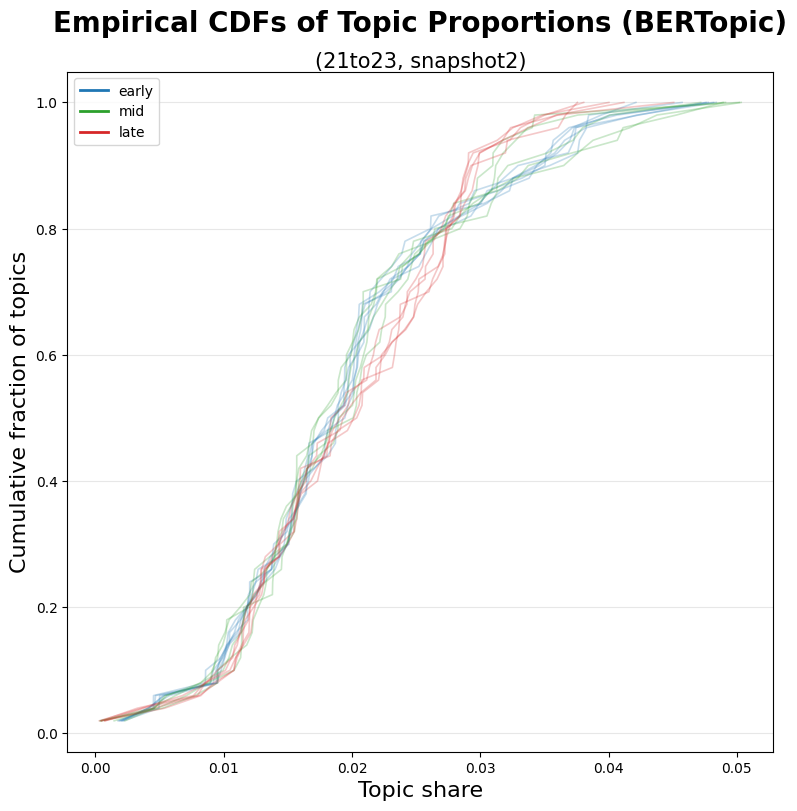

In [18]:
fig, axs = plt.subplots( figsize = (8, 8), constrained_layout=True)

weeks = list(np.sort(df['rel_week'].unique()))
window = 12
step = 6
n_windows = len(range(0, len(weeks) - window + 1, step))
for i, start in enumerate(range(0, len(weeks) - window + 1, step)):
    w_start = weeks[start]
    w_end = weeks[start + window - 1]

    subset = df[
        (df['rel_week'] >= w_start) &
        (df['rel_week'] <= w_end)
    ]
    if i < n_windows * 0.33:
        color = 'tab:blue'      # early
        label = 'early'
    elif i < n_windows * 0.66:
        color = 'tab:green'    # mid
        label = 'mid'
    else:
        color = 'tab:red'       # late
        label = 'late'

    prop_df = subset.groupby(['Topic']).count()['id'].reset_index().rename(columns={'id': 'cnt'})
    prop_df['pct'] = prop_df['cnt']/prop_df['cnt'].sum()


    values = prop_df['pct'].sort_values(ascending=False).values
    values = values[~np.isnan(values)]

    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)

    label = f"{int(w_start)}~{int(w_end)}"
    axs.plot(x, y,color=color,
        alpha=0.25,
        lw=1.2)

legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=2, label='early'),
    Line2D([0], [0], color='tab:green', lw=2, label='mid'),
    Line2D([0], [0], color='tab:red', lw=2, label='late'),
]

axs.legend(handles=legend_elements)
axs.grid(True, axis='y', alpha=0.3, linewidth=0.8)
axs.grid(False, axis='x')
axs.set_xlabel('Topic share', fontsize=16)
axs.set_ylabel('Cumulative fraction of topics', fontsize=16)

axs.text(0.5, 1.05, f"Empirical CDFs of Topic Proportions (BERTopic)",
            ha='center', va='bottom', fontsize=20, fontweight='bold', transform=axs.transAxes)

axs.text(0.5, 1.00, f"({option_dict['year_range']}, snapshot{option_dict['snapshot']})",
        ha='center', va='bottom', fontsize=15, transform=axs.transAxes)  

plt.show()


In [21]:
top10list, bot10list

([0, 1, 2, 4, 3, 6, 5, 7, 8, 10], [40, 39, 43, 41, 44, 45, 46, 47, 48, 49])

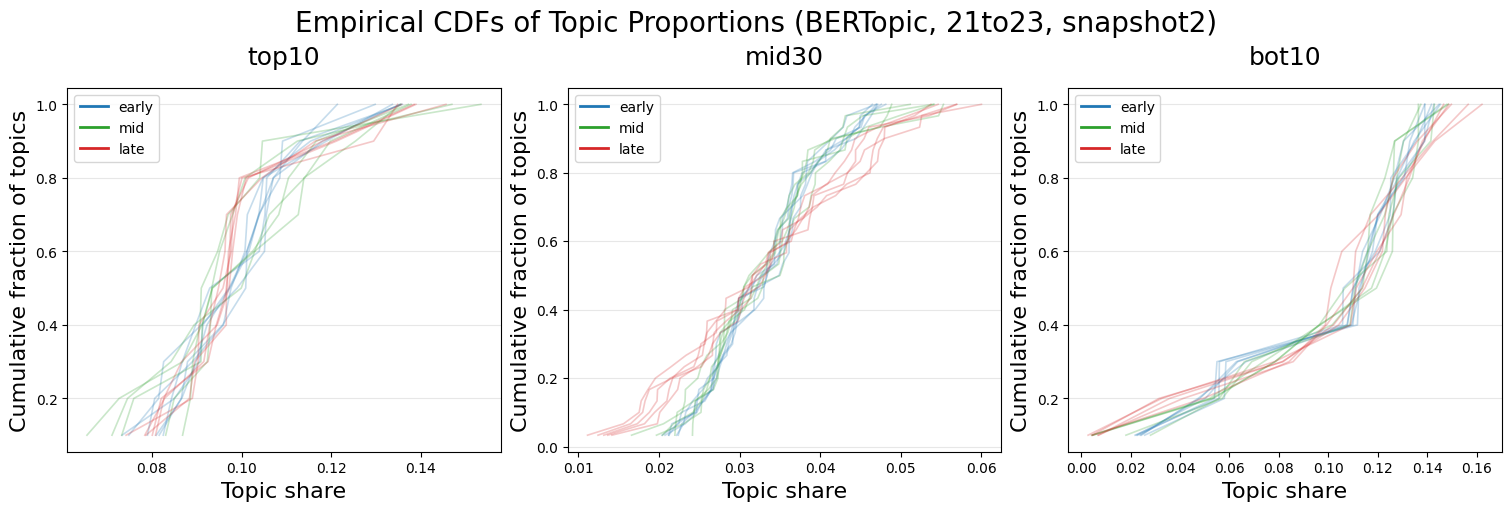

In [33]:
fig, axs = plt.subplots(1, 3, figsize = (15, 5), constrained_layout=True)

for idx, (topic_label, topic_list) in enumerate({"top10": top10list, "mid30": mid30list, "bot10": bot10list}.items()):
    weeks = list(np.sort(df['rel_week'].unique()))
    window = 12
    step = 6
    n_windows = len(range(0, len(weeks) - window + 1, step))
    for i, start in enumerate(range(0, len(weeks) - window + 1, step)):
        w_start = weeks[start]
        w_end = weeks[start + window - 1]

        subset = df[
            (df['rel_week'] >= w_start) &
            (df['rel_week'] <= w_end) &
            (df['Topic'].isin(topic_list))
        ]
        if i < n_windows * 0.33:
            color = 'tab:blue'      # early
            label = 'early'
        elif i < n_windows * 0.66:
            color = 'tab:green'    # mid
            label = 'mid'
        else:
            color = 'tab:red'       # late
            label = 'late'

        prop_df = subset.groupby(['Topic']).count()['id'].reset_index().rename(columns={'id': 'cnt'})
        prop_df['pct'] = prop_df['cnt']/prop_df['cnt'].sum()


        values = prop_df['pct'].sort_values(ascending=False).values
        values = values[~np.isnan(values)]

        x = np.sort(values)
        y = np.arange(1, len(x) + 1) / len(x)

        label = f"{int(w_start)}~{int(w_end)}"
        axs[idx].plot(x, y,color=color,
            alpha=0.25,
            lw=1.2)

    legend_elements = [
        Line2D([0], [0], color='tab:blue', lw=2, label='early'),
        Line2D([0], [0], color='tab:green', lw=2, label='mid'),
        Line2D([0], [0], color='tab:red', lw=2, label='late'),
    ]

    axs[idx].legend(handles=legend_elements)
    axs[idx].grid(True, axis='y', alpha=0.3, linewidth=0.8)
    axs[idx].grid(False, axis='x')
    axs[idx].set_xlabel('Topic share', fontsize=16)
    axs[idx].set_ylabel('Cumulative fraction of topics', fontsize=16)

    axs[idx].text(0.5, 1.05, f"{topic_label}",
                ha='center', va='bottom', fontsize=18, transform=axs[idx].transAxes)

    # axs[idx].text(0.5, 1.00, f"({option_dict['year_range']}, snapshot{option_dict['snapshot']})",
    #         ha='center', va='bottom', fontsize=15, transform=axs[idx].transAxes)  
fig.suptitle(f"Empirical CDFs of Topic Proportions (BERTopic, {option_dict['year_range']}, snapshot{option_dict['snapshot']})", fontsize=20)
plt.show()
